<a href="https://colab.research.google.com/github/jmoralespineda/TAM_TEORIA_APRENDIZAJE_DE_MAQUINA/blob/main/TAREA/4_Introduction_Recurrent_Neural_Networks_Tarea13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Procesamiento de secuencias con redes neuronales recurrentes

- En general, muchos problemas en ciencia de datos, requieren del procesado de datos sencuenciales, generalmente asociados al tiempo (series de tiempo).

- En ese sentido, sea la serie de datos $\{x_t\in\mathbb{R}\}_{t=1}^T$.

- Suponga que se define el modelo predictivo probabilístico de la forma:

$$x_t \sim P(x_t|x_{t-1},\dots,x_1)$$

- En general, el estudio de datos secuenciales se puede atacar desde dos aproximaciones básicas: i) modelos autorregresivos , y ii) modelos autorregresivos de variable latente.

# Modelos autorregresivos

- Dichos modelos fijan una dependencia temporal de orden $\tau$.

- Por ende, el número de puntos requeridos para realizar predicciones para $t > \tau$ se mantiene fijo, dado que se asume:

$$x_t \sim P(x_t|x_{t-1},\dots,x_{t-\tau})$$

# Modelos autorregresivos de variable latente

- Buscan preservar alguna representación latente (memoría) $h_t$ de las observaciones pasadas, y busca actualizar (predecir) la secuencia $x_t$ y la variable latente $h_t$, de la forma:

$$\hat{x}_t = P(x_t|h_t)$$

$$h_t = g(h_{t-1},x_{t-1})$$

![autorregresivo](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/autorregresivo.png?raw=1)

**Nota**: $h_t$ no es observable (latente), por ende debe estimarse desde los datos.

- En estadística, el concepto de dinámica que no cambia (patrón regular) se conoce como estacionario. En este sentido, podemos tener un estimado de la secuencia completa utilizando un modelo probabilístico de la forma:

$$P(x_1,x_2,\dots,x_T) = \prod^T_{t=1}P(x_t|x_{t-1},\dots,x_1)$$
donde el estimado de la probabilidad condicional se puede realizar mediante regresores o clasficadores para eventos continuos o discretos, respectivamente.



# Modelos Markovianos

- En los modelos autorregresivos la estimación de $x_t$ se basa en una ventana de tamaño $\tau$, de la forma $x_{t-1},\dots,x_{t-\tau}$.

- Para cuando dicha aproximación es correcta, se dice que la secuencia de datos cumple con la condición Markoviana.

- Para $\tau=1$, se tiene un modelo de Markov de primer orden:

$$P(x_1,x_2,\dots,x_T)=\prod_{t=1}^T P(x_t|x_{t-1})$$
con $P(x_1|x_0)=P(x_1).$





# Ejercicio 1:

- Consultar el modelo y principio de optimización de los modelos de media móvil ([Moving average - MA](https://en.wikipedia.org/wiki/Moving-average_model)), autorregresivos de media móvil ([Autorregresive moving average - ARMA](https://en.wikipedia.org/wiki/Autoregressive%E2%80%93moving-average_model)) y autorregresivo integrado de media móvil ([Autoregressive integrated moving average](https://en.wikipedia.org/wiki/Autoregressive_integrated_moving_average)). Cuáles son sus relaciones con los modelos Markovianos?.

# Modelos MA, ARMA y ARIMA y su relación con los modelos Markovianos

## 1. Modelo de Media Móvil (MA)

El modelo **MA(q)** (Moving Average) describe una serie temporal como una combinación lineal de los **errores aleatorios pasados**.
Matemáticamente:

$$
X_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}
$$

donde:
- \( $X_t $) es el valor de la serie en el tiempo \( t \),
- \( $mu $) es la media de la serie,
- \( $\varepsilon_t $) es un término de ruido blanco (\( $\varepsilon_t \sim N(0, \sigma^2)$)),
- \( $\theta_i \$) son los coeficientes del modelo MA.

🔹 **Principio de optimización:**
Los parámetros \( \theta_i \) se ajustan minimizando el **error cuadrático medio (MSE)** entre los valores observados y los predichos.
El ajuste se realiza típicamente mediante **máxima verosimilitud (MLE)** o **mínimos cuadrados**.

* * *

## 2. Modelo Autorregresivo de Media Móvil (ARMA)

El modelo **ARMA(p, q)** combina los componentes **autorregresivo (AR)** y **de media móvil (MA)**, capturando tanto la dependencia con valores pasados como con errores previos:

$$
X_t = c + \sum_{i=1}^{p} \phi_i X_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

donde:
- \( $\phi_i $) son los coeficientes autorregresivos,
- \( $\theta_j $) son los coeficientes de media móvil,
- \($ c \$) es una constante.

🔹 **Principio de optimización:**
Se busca maximizar la **función de verosimilitud** de los datos dados los parámetros del modelo o minimizar el **Akaike Information Criterion (AIC)** o el **Bayesian Information Criterion (BIC)** para seleccionar los órdenes óptimos \(p\) y \(q\).

* * *

##  3. Modelo Autorregresivo Integrado de Media Móvil (ARIMA)

El modelo **ARIMA(p, d, q)** extiende el ARMA incluyendo un componente de **integración (I)**, que representa el número de **diferenciaciones** necesarias para volver estacionaria una serie no estacionaria:

$$
\nabla^d X_t = c + \sum_{i=1}^{p} \phi_i \nabla^d X_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

donde \( $\nabla^d X_t = (1 - B)^d X_t \) y \( B \$) es el operador de rezago.

🔹 **Principio de optimización:**
Se optimizan los parámetros \(p, d, q\) mediante:
- **Máxima verosimilitud (MLE)**,
- **AIC/BIC** para seleccionar el modelo más parsimonioso,
- **Gradiente descendente o métodos iterativos de optimización no lineal** en la estimación de parámetros.

* * *

##  4. Relación con los Modelos Markovianos

Los modelos **AR**, **MA**, **ARMA** y **ARIMA** están conceptualmente relacionados con los **Modelos de Markov** por su **dependencia en estados pasados**:

| Modelo | Tipo de Dependencia | Naturaleza Markoviana |
|---------|---------------------|------------------------|
| **AR(p)** | Depende de los últimos \(p\) valores de la serie | Es un **proceso de Markov de orden \(p\)** |
| **MA(q)** | Depende de los últimos \(q\) errores aleatorios | No estrictamente Markoviano, pero puede representarse en un espacio de estados |
| **ARMA(p,q)** | Combina valores pasados y errores previos | Puede representarse como un **modelo de espacio de estados** con propiedad de Markov |
| **ARIMA(p,d,q)** | Incluye diferenciación (memoria acumulada) | Se aproxima a un proceso Markoviano después de diferenciar la serie \(d\) veces |

En resumen, los modelos AR, ARMA y ARIMA **pueden representarse como procesos de Markov** cuando el sistema se formula en términos de **vectores de estado**, donde el estado incluye los valores pasados relevantes para predecir el futuro.

* * *

##  Conclusión

Los modelos **MA**, **ARMA** y **ARIMA** constituyen la base clásica del análisis de series temporales.
Su principio de optimización se fundamenta en **minimizar el error y maximizar la verosimilitud** de los parámetros bajo supuestos de ruido blanco y estacionariedad.
Su relación con los modelos **Markovianos** radica en la **dependencia limitada del pasado**, lo que les confiere la propiedad de **memoria finita**, característica central de los procesos de Markov.

* * *


# Redes neuronales recurrentes - Recurrent neural networks (RNN)

- Hasta el momento hemos trabajado con datos estructurados tipo tabla, en donde las muestras se asumen independientes e identicamente distribuidas (i.i.d.).

- Sin embargo, para datos secuenciales, la suposición i.i.d no es apropiada, y se requiren de arquitecturas que codifiquen dicha secuencialidad.

- Por ejemplo, en el caso de datos tipo imagen, la relación espacial debe ser codificada apropiadamente, como en el caso de las arquitecturas convolucionales ([Convolutional Neural Networks](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/3_Introduccion_CNN.ipynb)).

- En este sentido, las RNN pretenden explotar la codificación mediante variables latentes, para aproximar el modelado de la incertidumbre de la secuencia como:


$$P(x_t|x_{t-1},\dots,x_1)\approx P(x_t|h_{t-1})$$

donde el estado oculto $h_{t-1}$ (hidden state) codifica la información relevante de la secuencia hasta $t-1$.

- Además, el estado oculto en $t$ se puede calcular a partir de $x_t$ y $h_{t-1},$ como:

$$h_t=f(x_t,h_{t-1})$$

**Nota**: se podría utilizar como $h_t$ todo el vector de datos $x_t,x_{t-1},\dots,x_1$; no obstante, el costo computacional y de memoría sería muy alto.

## Las RNN son redes neuronales con estados ocultos!

- Considere una matriz (mini-lote) de $P$ características desde datos secuenciales $\mathbf{X}_t\in\mathbb{R}^{N\times P}$, es decir, tenemos $N$ trayectorias con $P$ mediciones de una secuencia en el instante $t$.

- Sea $\mathbf{H}_t\in\mathbb{R}^{N \times h}$ la variable oculta (latente) para el instante $t$, la estimación de dicha variable respecto a la entrada actual y a la variable oculta en $t-1$ se puede modelar mediante RNN como:

$$\mathbf{H}_t = \phi(\mathbf{X}_t \mathbf{W}+\mathbf{H}_{t-1}\mathbf{S} + \mathbf{b}),$$

donde $\mathbf{W}\in\mathbb{R}^{P \times h},$ $\mathbf{S}\in\mathbb{R}^{h \times h},$ $\mathbf{b}\in\mathbb{R}^{h}$ y $\phi(\cdot)$ es una función de activación no lineal.

- Si se desea calcular la salida $\mathbf{O}_t\in\mathbb{R}^{N\times Q}$, se puede utilizar la información del estado oculto de la forma:

$$\mathbf{O}_t = \mathbf{H}_t\mathbf{A}+\mathbf{c},$$
donde $\mathbf{A}\in\mathbb{R}^{h\times Q}$, $\mathbf{c}\in\mathbb{R}^{Q}.$

**Esquema de una RNN con un estado oculto:**

![rnn](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/rnn.png?raw=1)



- A continuación se presenta algunos ejemplos sobre Tensorflow para RNN.

In [1]:
import sys
import sklearn
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
#-------------------------------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)
#-------------------------------------------------------------------------------
#
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
#-------------------------------------------------------------------------------

Generamos el conjunto de series de tiempo a analizar

In [2]:
#-------------------------------------------------------------------------------
# definimos función para generar señales 1D-------------------------------------
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time   = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)
#-------------------------------------------------------------------------------

In [3]:
#-------------------------------------------------------------------------------
# definimos número de steps y batch_size----------------------------------------
n_steps    = 50
batch_size = 10000
#-------------------------------------------------------------------------------
series           = generate_time_series(batch_size, n_steps + 1)
print('Series dimension:',series.shape)
#-------------------------------------------------------------------------------
# partimos en conjuntos de train/valid/test-------------------------------------
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]
#-------------------------------------------------------------------------------
print('Train dimensions:',X_train.shape, y_train.shape)
print('Valid dimensions:',X_valid.shape, y_valid.shape)
print('Test dimensions:',X_test.shape, y_test.shape)
#-------------------------------------------------------------------------------

Series dimension: (10000, 51, 1)
Train dimensions: (7000, 50, 1) (7000, 1)
Valid dimensions: (2000, 50, 1) (2000, 1)
Test dimensions: (1000, 50, 1) (1000, 1)


$[y_{t+P},\dots,y_{t}] = f(y_{t-1},\dots,y_{t-\tau},x_{t},x_{t-1},\dots,x_{t-\tau})$

In [4]:
#-------------------------------------------------------------------------------
y_train # vector de salida
#-------------------------------------------------------------------------------

array([[-0.35489398],
       [ 0.11629631],
       [-0.35395944],
       ...,
       [ 0.04946356],
       [-0.26231018],
       [ 0.60062087]], dtype=float32)

Generamos la gráfica de las series de tiempo creadas

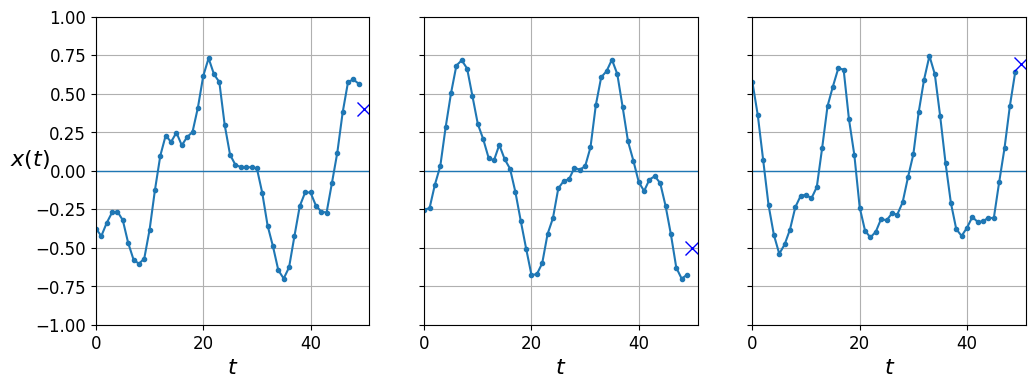

In [5]:
#-------------------------------------------------------------------------------
# definimos función para graficar las series------------------------------------
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])
#-------------------------------------------------------------------------------
# graficamos 3 series del set validation----------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None))
plt.show()
#-------------------------------------------------------------------------------

# Predicción ingenua (solo predecir el último valor):

- Para ilustrar el concepto de secuencialidad, utilizaremos un predictor ingenuo, en donde la salida actual sería igual al valor en el instante anterior:

$$x_t = x_{t-1}$$

In [6]:
#-------------------------------------------------------------------------------
# asumimos que el valor ha estimar es el último elemento de la serie----------------
y_pred = X_test[:, -1]
#-------------------------------------------------------------------------------
# calculamos el MSE entre el y_valid vs. y_pred---------------------------------

print('MSE:',np.mean(keras.losses.mse(y_test, y_pred))*100,'%')
#-------------------------------------------------------------------------------

MSE: 2.1811275 %


- El error cálculado no es tan grande aparentemente.

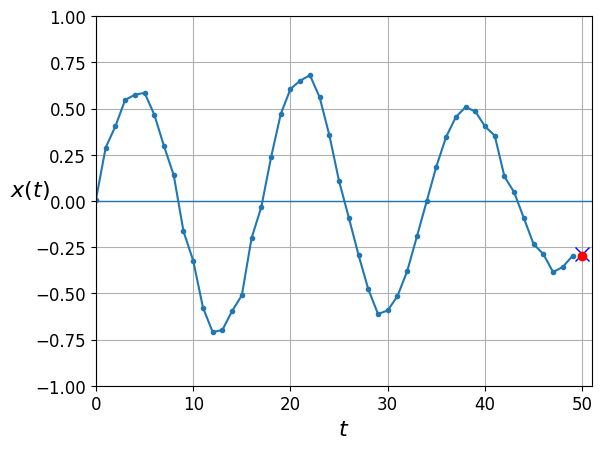

In [7]:
#-------------------------------------------------------------------------------
# graficamos valor estimado----------------------------------------------------
plot_series(X_test[2, :, 0], y_test[2, 0], y_pred[2, 0])
plt.show()
#-------------------------------------------------------------------------------

# Predicción lineal

- Ahora utilizaremos un modelo lineal simple.

- Recuerde que como generamos ventanas, podrimos entender esta aproximación como un modelo autorregresivo simple (sin variables latentes):

$$x_t \sim P(x_t|x_{t-1},\dots,x_{t-\tau})$$

donde la estimación de la condicional se realiza mediante un regresor con capas densas.



$\mathbf{X}=[\mathbf{x}_n]\in \mathbb{R}^{N \times P}$

$\mathbf{x}_n =[y_{n-1},y_{n-2},\dots, y_{n-\tau}]$

$\mathbf{y}\in \mathbb{R}^T$

$f(\mathbf{x}_n)=\mathbf{x}_n\mathbf{w}=x_{n1}w_1+\dots+x_{nP}w_P$

$f(\mathbf{x}_n)= y_{n-1}w_1+\dots+y_{n-\tau}w_P = \hat{y}_n$

$P = \tau$

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

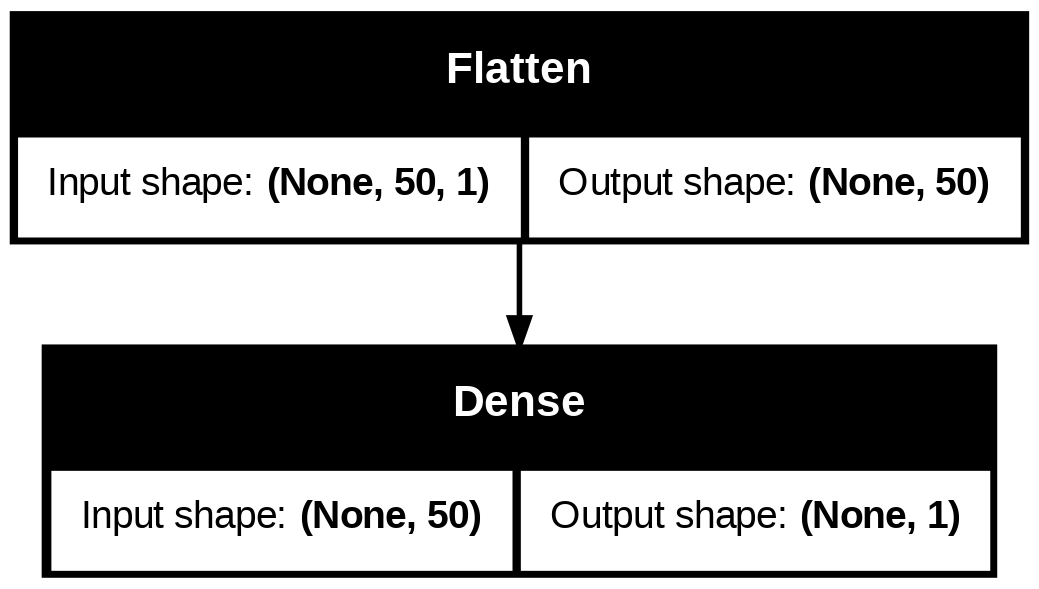

In [8]:
#-------------------------------------------------------------------------------
# definimos un modelo secuencial------------------------------------------------
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])
#-------------------------------------------------------------------------------
model.summary()
#-------------------------------------------------------------------------------
keras.utils.plot_model(model, "my_model_series.png", show_shapes=True)
#-------------------------------------------------------------------------------

Compilamos y ajustamos el modelo usando los datos de train y validation

In [9]:
epochs = 20
#-------------------------------------------------------------------------------
model.compile(loss="mse", optimizer="adam")
#-------------------------------------------------------------------------------
history = model.fit(X_train, y_train, epochs=epochs,
                    validation_data=(X_valid, y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1367 - val_loss: 0.0335
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0257 - val_loss: 0.0174
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0155 - val_loss: 0.0130
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0119 - val_loss: 0.0109
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0099 - val_loss: 0.0095
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0087 - val_loss: 0.0085
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0078 - val_loss: 0.0077
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0071 - val_loss: 0.0070
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0065
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0056 - val_loss: 0.0057
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [10]:
#-------------------------------------------------------------------------------
# verificamos evluación del modelo---------------------------------------------
y_pred = model.predict(X_test)
print('MSE:',np.mean(keras.losses.mse(y_test, y_pred))*100,'%')
#-------------------------------------------------------------------------------

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
MSE: 0.3919666 %


El resultado es mucho mejor que el predictor ingenuo.

Graficamos el desempeño del modelo secuencial

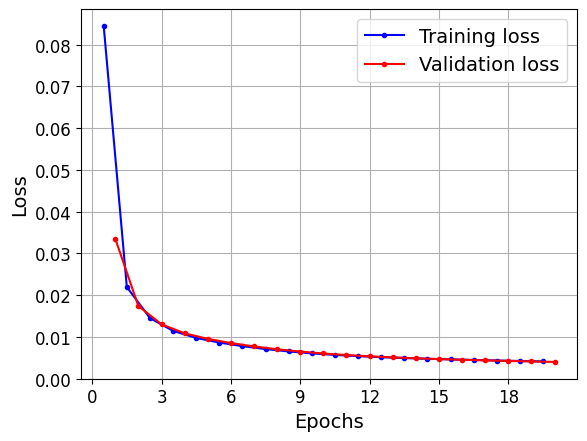

In [11]:
#-------------------------------------------------------------------------------
# definimos una función para plot de curvas de aprendizaje----------------------
def plot_learning_curves(loss, val_loss):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    #plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)
#-------------------------------------------------------------------------------
# llamamos función de plot------------------------------------------------------
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()
#-------------------------------------------------------------------------------

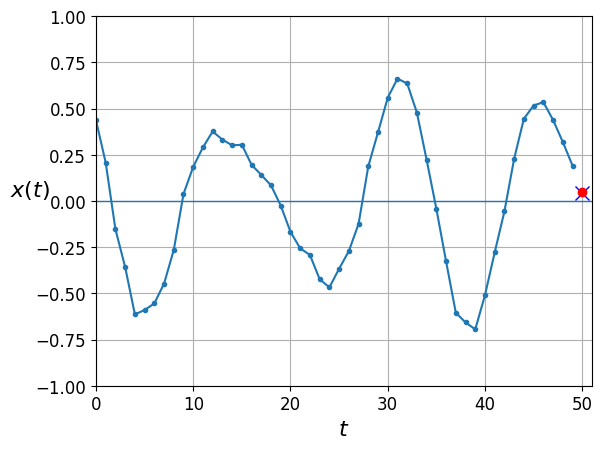

In [12]:
#-------------------------------------------------------------------------------
# pintamos series y predicciones------------------------------------------------
plot_series(X_test[0, :, 0], y_test[0, 0], y_pred[0, 0])
plt.show()
#-------------------------------------------------------------------------------

# Predicciones con RNN

- Keras tiene implementado las [capas simples de RNN](https://keras.io/api/layers/recurrent_layers/simple_rnn/).

- Por defecto la activación no lineal utilizada es la `tanh`, aunque se puede trabajar con las vistas en módulos anteriores.

- En este caso se define una única capa RNN con una neurona, dado que tenemos una única salida a predecir.

In [13]:
#-------------------------------------------------------------------------------
# definimos modelo secuencial de RNN simple-------------------------------------
model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1], )
])
#-------------------------------------------------------------------------------
# compilamos el modelo RNN------------------------------------------------------
optimizer = keras.optimizers.Adam(learning_rate=0.005)
model.compile(loss="mse", optimizer=optimizer)
#-------------------------------------------------------------------------------
# entrenamos el modelo y lo ajustamos con los datos de valid--------------------
history = model.fit(X_train, y_train, epochs=epochs,
                    validation_data=(X_valid, y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1865 - val_loss: 0.0413
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0365 - val_loss: 0.0272
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0253 - val_loss: 0.0206
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0198 - val_loss: 0.0169
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0166 - val_loss: 0.0146
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0145 - val_loss: 0.0131
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0132 - val_loss: 0.0121
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0124 - val_loss: 0.0115
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0119 - val_loss: 0.0112
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0116 - val_loss: 0.0110
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0115 - val_loss: 0.0109
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0

In [14]:
#-------------------------------------------------------------------------------
# verificamos evluación del modelo---------------------------------------------
y_pred = model.predict(X_test)
print('MSE:',np.mean(keras.losses.mse(y_test, y_pred))*100,'%')
#-------------------------------------------------------------------------------

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
MSE: 1.1334296 %


Graficamos el performance de la Simple RNN

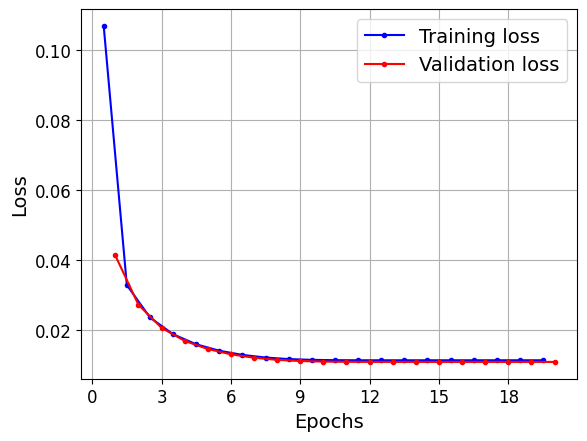

In [15]:
#-------------------------------------------------------------------------------
# graficamos curvas de aprendizaje----------------------------------------------
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()
#-------------------------------------------------------------------------------

Se analiza la predicción

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


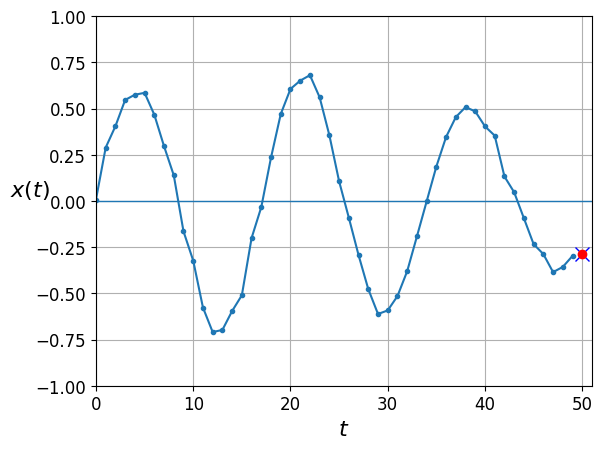

In [16]:
#-------------------------------------------------------------------------------
# evaluamos sobre set de X_valid------------------------------------------------
y_pred = model.predict(X_test)
# pintamos la serie y la predicción---------------------------------------------
plot_series(X_test[2, :, 0], y_test[2, 0], y_pred[2, 0])
plt.show()
#-------------------------------------------------------------------------------

# Deep RNNs

- Un modelo profundo de RNN contiene $L$ capas ocultas.

- Sobre cada capa oculta, el estado oculto es actualizado y se pasa al siguiente instante de tiempo de la capa actual y de la capa siguiente:

![deeprnn](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/deeprnn.png?raw=1)

- El modelo recurrente profundo se define entonces como:

$$\mathbf{H}^{(l)}_t = \phi_l\left(\mathbf{H}^{(l-1)}_t \mathbf{W}^{(l)}+\mathbf{H}^{(l)}_{t-1}\mathbf{S}^{(l)} + \mathbf{b}^{(l)}\right),$$

donde $\mathbf{W}^{(l)}\in\mathbb{R}^{h_{l-1} \times h_l},$ $\mathbf{S}^{(l)}\in\mathbb{R}^{h_{l-1} \times h_{l-1}},$ $\mathbf{b}\in\mathbb{R}^{h_l}$ y $\phi_l(\cdot)$ es una función de activación no lineal. $\mathbf{H}^{(0)}_t=\mathbf{X}_t$

- Si se desea calcular la salida $\mathbf{O}_t\in\mathbb{R}^{N\times Q}$, se puede utilizar la información del estado oculto en la capa oculta $L$:

$$\mathbf{O}_t = \mathbf{H}^{(L)}_t\mathbf{A}+\mathbf{c},$$
donde $\mathbf{A}\in\mathbb{R}^{h_L\times Q}$, $\mathbf{c}\in\mathbb{R}^{Q}.$


**Nota:** para aplicar la capa densa de la salida, se puede utilizar una capa `SimpleRNN(1)` con una neurona, o una capa densa aplicada desde la capa [TimeDistributed](https://keras.io/api/layers/recurrent_layers/time_distributed/) para preservar la temporalidad de los datos.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 1)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

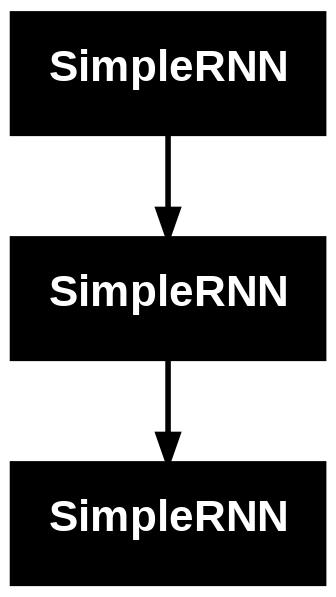

In [17]:
#-------------------------------------------------------------------------------
# definimos el modelo Deep RNN como un stack de SimpleRNN-----------------------
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1,activation='linear')
    ])
#-------------------------------------------------------------------------------
# pintamos el diagrama de bloques del modelo
model.summary()
tf.keras.utils.plot_model(model)
#-------------------------------------------------------------------------------

# Ejercicio 2

- Para el modelo definido, determine los tamaños de las matrices y vectores de bias en cada capa.

**Nota**: Utilice el método `model.layers[l].get_weights()`

In [18]:
# --------------------------------------------------------------
# Inspeccionar las dimensiones de los pesos y bias en cada capa
# --------------------------------------------------------------

for i, layer in enumerate(model.layers):
    print(f"\n📘 Capa {i+1}: {layer.name}")

    # Extraer pesos: [kernel, recurrent_kernel, bias]
    W, S, b = layer.get_weights()

    # Mostrar dimensiones
    print(f" - kernel (W): {W.shape}")
    print(f" - recurrent_kernel (S): {S.shape}")
    print(f" - bias (b): {b.shape}")



📘 Capa 1: simple_rnn_1
 - kernel (W): (1, 20)
 - recurrent_kernel (S): (20, 20)
 - bias (b): (20,)

📘 Capa 2: simple_rnn_2
 - kernel (W): (20, 20)
 - recurrent_kernel (S): (20, 20)
 - bias (b): (20,)

📘 Capa 3: simple_rnn_3
 - kernel (W): (20, 1)
 - recurrent_kernel (S): (1, 1)
 - bias (b): (1,)


In [ ]:
# --------------------------------------------------------------
# Calcular el número total de parámetros
# --------------------------------------------------------------
total_params = np.sum([np.prod(w.shape) for layer in model.layers for w in layer.get_weights()])
print(f"\n🔢 Número total de parámetros entrenables: {total_params}")


In [19]:
# compilamos el modelo----------------------------------------------------------
model.compile(loss="mse", optimizer="adam")
#-------------------------------------------------------------------------------
# entrenamos y ajustamos el modelo----------------------------------------------
history = model.fit(X_train, y_train, epochs=epochs,
                    validation_data=(X_valid, y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0833 - val_loss: 0.0066
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0055 - val_loss: 0.0043
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 

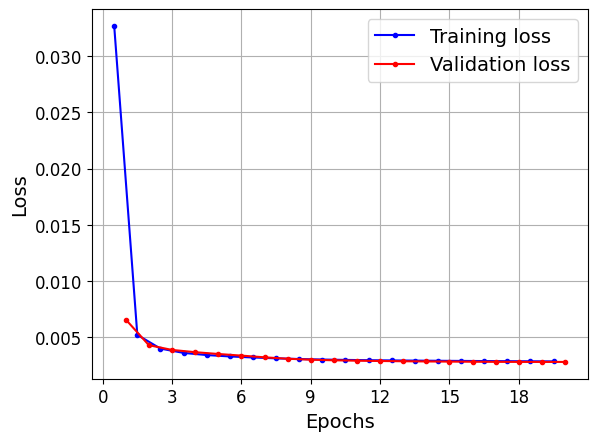

In [20]:
#-------------------------------------------------------------------------------
# graficamos curvas de aprendizaje----------------------------------------------
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()
#-------------------------------------------------------------------------------

In [21]:
y_train.shape

(7000, 1)

In [22]:
#-------------------------------------------------------------------------------
# verificamos evluación del modelo---------------------------------------------
y_pred = model.predict(X_test)
#print('MSE:',np.mean(keras.losses.mean_squared_error(y_test, y_pred))*100,'%')
#-------------------------------------------------------------------------------
y_pred.shape

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


(1000, 1)

Graficamos el performance de la Deep RNN

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


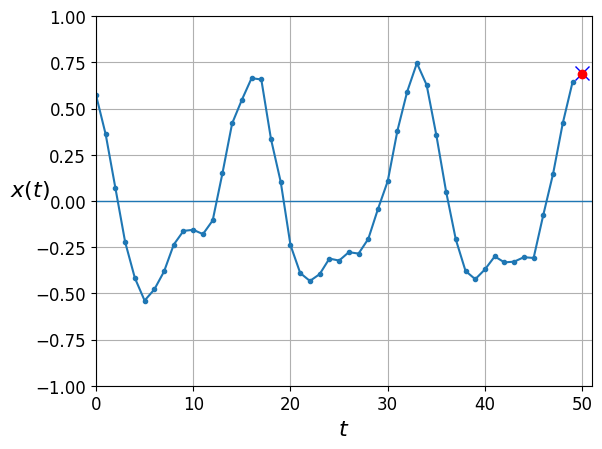

In [23]:
#-------------------------------------------------------------------------------
# evaluamos sobre set de X_valid------------------------------------------------
y_pred = model.predict(X_valid)
# pintamos la serie y la predicción---------------------------------------------
plot_series(X_valid[2, :, 0], y_valid[2, 0], y_pred[2, 0])
plt.show()
#-------------------------------------------------------------------------------

# Predicir un horizonte más lejano

- Si concatenamos las predicciones de a una muestra, para generar salidas con horizontes más lejanos, podemos estar propangando el error!

In [24]:
#-------------------------------------------------------------------------------
# definimos nueva semilla aleatoria---------------------------------------------
np.random.seed(43) #
#-------------------------------------------------------------------------------
# generamos nueva series de tiempo----------------------------------------------
series       = generate_time_series(1, n_steps + 10)     # horizonte de 10 valores en el tiempo
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]
X            = X_new
for step_ahead in range(10):
    y_pred_one = model.predict(X[:, step_ahead:])[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)
#-------------------------------------------------------------------------------
Y_pred = X[:, n_steps:]
#-------------------------------------------------------------------------------

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [25]:
#-------------------------------------------------------------------------------
# observamos nuevas dimensiones de Y_pred---------------------------------------
Y_pred.shape #horizonte de 10 valores en el tiempo
#-------------------------------------------------------------------------------

(1, 10, 1)

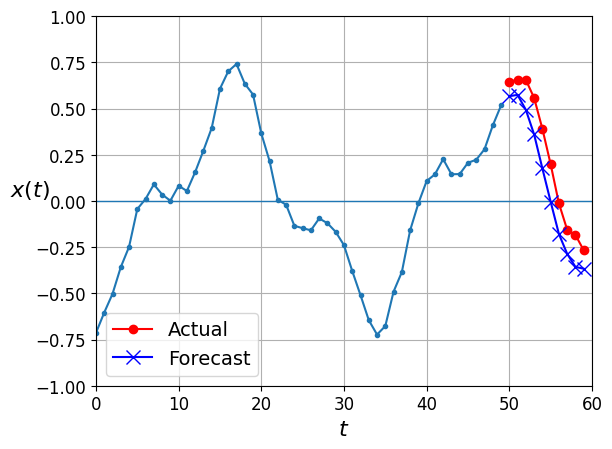

In [26]:
#-------------------------------------------------------------------------------
# definimos función para pintar forecast----------------------------------------
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)
#-------------------------------------------------------------------------------
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()
#-------------------------------------------------------------------------------

- Lo mejor es entrenar un modelo que incluya como salida target los siguientes $T$ valores a predicir en el horizonte.

- Se requiere entonces generar nuevamente la secuencia con $T-1$ pasos más en el tiempo.

In [27]:
#-------------------------------------------------------------------------------
# definimos semilla aleatoria---------------------------------------------------
np.random.seed(42)
#-------------------------------------------------------------------------------
n_steps = 50
series = generate_time_series(10000, n_steps + 10)
print('Series dimension:',series.shape)
X_train, Y_train = series[:7000, :n_steps], series[:7000, -10:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -10:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -10:, 0]
#-------------------------------------------------------------------------------
print('Train dimensions:',X_train.shape, Y_train.shape)
print('Valid dimensions:',X_valid.shape, Y_valid.shape)
print('Test dimensions:',X_test.shape, Y_test.shape)
#-------------------------------------------------------------------------------

Series dimension: (10000, 60, 1)
Train dimensions: (7000, 50, 1) (7000, 10)
Valid dimensions: (2000, 50, 1) (2000, 10)
Test dimensions: (1000, 50, 1) (1000, 10)


Predicción de los siguientes 10 valores (uno a uno y concatenar):

In [28]:
#-------------------------------------------------------------------------------
# realizamos predicción usando modelo Deep RNN----------------------------------
del X
X = X_valid
for step_ahead in range(10):
    y_pred_one = model.predict(X)[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)
#-------------------------------------------------------------------------------
# obtenemos las predicciones de los siguientes 10 valores-----------------------
Y_pred = X[:, n_steps:, 0]
#-------------------------------------------------------------------------------
print('Y_pred dimensions:', Y_pred.shape)
#-------------------------------------------------------------------------------

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Y_pred dimensions: (2000, 10)


- Error de predicción con horizontes mayores a 1 concatenando salidas:

In [29]:
#-------------------------------------------------------------------------------
# calculamos el MSE de la predicción--------------------------------------------
print(np.mean(keras.metrics.mse(Y_valid, Y_pred))*100,'%')
#-------------------------------------------------------------------------------

2.7808218 %


Ahora se crea una RNN que permita predecir los siguientes 10 valores en una sola evaluación (predicción multi-salida):

In [30]:
#-------------------------------------------------------------------------------
# definimos semillas aleatorias-------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)
#-------------------------------------------------------------------------------
# definimos el modelo secuencial multi-salida-----------------------------------
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10) # capa densa para estimar los siguientes 10 valores
])
#-------------------------------------------------------------------------------
# compilamos el modelo----------------------------------------------------------
model.compile(loss="mse", optimizer="adam")
#-------------------------------------------------------------------------------
# entrenamos y ajustamos el modelo----------------------------------------------
history = model.fit(X_train, Y_train, epochs=epochs,
                    validation_data=(X_valid, Y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.1033 - val_loss: 0.0277
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0249 - val_loss: 0.0183
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0180 - val_loss: 0.0158
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0150 - val_loss: 0.0143
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0133 - val_loss: 0.0148
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0121 - val_loss: 0.0130
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0112 - val_loss: 0.0123
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0107 - val_loss: 0.0104
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0104 - val_loss: 0.0099
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0101 - val_loss: 0.0094
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0099 - val_loss: 0.0091
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss:

In [31]:
#-------------------------------------------------------------------------------
# generamos nuevos datos, con nueva semilla aleatoria---------------------------
np.random.seed(43)
#-------------------------------------------------------------------------------
# generamos nueva serie de tiempo-----------------------------------------------
series       = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, -10:, :]
#-------------------------------------------------------------------------------
print('X_new dimensions:',X_new.shape)
print('Y_new dimensions:',Y_new.shape)
#-------------------------------------------------------------------------------
# hacemos predicción de los 10 últimos valores----------------------------------
Y_pred       = model.predict(X_new)[..., np.newaxis]
print('Y_pred dimensions:',Y_pred.shape)
#-------------------------------------------------------------------------------

X_new dimensions: (1, 50, 1)
Y_new dimensions: (1, 10, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
Y_pred dimensions: (1, 10, 1)


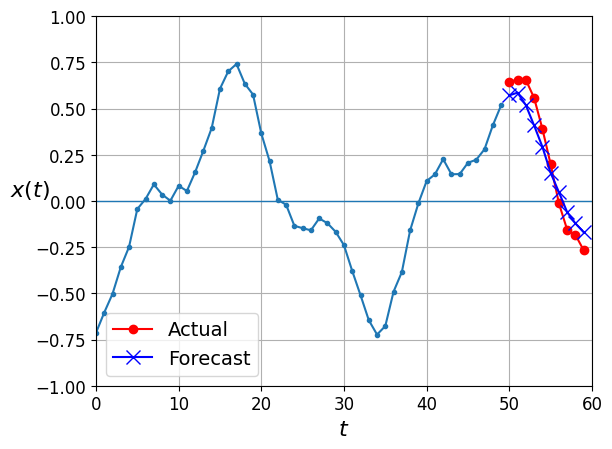

In [32]:
#-------------------------------------------------------------------------------
# graficamos el forecast--------------------------------------------------------
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()
#-------------------------------------------------------------------------------

- El error de predicción mejora:

In [33]:
#-------------------------------------------------------------------------------
# calculamos el MSE de la predicción--------------------------------------------
print(np.mean(keras.metrics.mse(Y_new, Y_pred))*100,'%')

0.89195734 %


# El problema de las dependencias a largo plazo

- Uno de los atractivos de los RNN es la idea de conectar la información anterior a la tarea actual. Si los RNN pudieran hacer esto, serían extremadamente útiles.

- A veces, solo necesitamos mirar información reciente para realizar la tarea actual.

- Por ejemplo, considere un modelo de lenguaje que intenta predecir la siguiente palabra basándose en las anteriores. Si estamos tratando de predecir la última palabra en la oración:

 "las nubes están en el cielo",

no necesitamos ningún contexto adicional; es bastante obvio que la siguiente palabra será **cielo**.

- En tales casos, donde la brecha entre la información relevante y el lugar que se necesita es pequeña, los RNN pueden aprender a usar la información del pasado.

![rnn_corto](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/rnn_corto.png?raw=1)

- Pero también hay casos en los que necesitamos más contexto. Considere intentar predecir la última palabra del texto:

"Crecí en Francia ... hablo francés con fluidez",

la información reciente sugiere que la siguiente palabra es probablemente el **nombre de un idioma**, pero si queremos delimitar qué idioma, necesitamos el contexto de Francia, desde más atrás.

- Entonces, la brecha entre la información relevante y el punto donde se necesita puede ser grande.

![rnn_largo](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/rnn_largo.png?raw=1)

- En teoría, los RNN son capaces de manejar tales "dependencias a largo plazo". Lamentablemente, en la práctica, las RNN no parecen ser capaces de aprenderlos.

# [LSTM](https://colah.github.io/posts/2015-08-Understanding-LSTMs/): Long short term memory

- La LSTM pretende aprender dependencias largas.

- En general, en LSTM, y su extensión GRU, buscan crear mecanismos que permitan identificar cuando el estado oculto debe ser actualizado y cuando reseteado.

- A diferencia de una capa RNN simple, las LSTMs presenta cuatro (4) capas interactuando:


![lstm](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/lstm.png?raw=1)

con:

$$\mathbf{I}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xi}+\mathbf{H}_{t-1}\mathbf{W}_{hi}+\mathbf{b}_i\right)$$
$$\mathbf{F}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xf}+\mathbf{H}_{t-1}\mathbf{W}_{hf}+\mathbf{b}_f\right)$$
$$\mathbf{O}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xo}+\mathbf{H}_{t-1}\mathbf{W}_{ho}+\mathbf{b}_o\right)$$
$$\tilde{\mathbf{C}}_t = \tanh\left(\mathbf{X}_t\mathbf{W}_{xc}+\mathbf{H}_{t-1}\mathbf{W}_{hc}+\mathbf{b}_c\right)$$
$${\mathbf{C}}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t $$
$${\mathbf{H}}_t = \mathbf{O}_t \odot \tanh{(\mathbf{C}_{t})} $$


donde $\mathbf{W}_{xi},\mathbf{W}_{xf},\mathbf{W}_{xo}, \mathbf{W}_{xc}\in\mathbb{R}^{P\times h},$ $\mathbf{W}_{hi},\mathbf{W}_{hf},\mathbf{W}_{ho},\mathbf{W}_{hc}\in\mathbb{R}^{h\times h}$ y $\mathbf{b}_{i},\mathbf{b}_{f},\mathbf{b}_{o}, \mathbf{b}_{c}\in\mathbb{R}^{h}$.

- $\mathbf{I}_t$ busca codificar "cuanto" considerar de los datos nuevos y $\mathbf{F}_t$ que tando retenemos de los datos del pasado.

- Si la compuerta de salida se aproxima a 1, pasamos toda la información de la memoría al predictor, pero, si la compuerta de la salida aproxima a 0, se retiene la información en la celda de memoría.


In [34]:
#-------------------------------------------------------------------------------
# generamos los datos-----------------------------------------------------------
np.random.seed(42)
#-------------------------------------------------------------------------------
# generamos series de tiempo----------------------------------------------------
n_steps = 50
series  = generate_time_series(10000, n_steps + 10)
print('Series dimensions:',series.shape)
#-------------------------------------------------------------------------------
# partimos los datos en train/valid/test----------------------------------------
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test  = series[9000:, :n_steps]
print('X_train dimensions:',X_train.shape)
print('X_valid dimensions:',X_valid.shape)
print('X_test dimensions:',X_test.shape)
#-------------------------------------------------------------------------------
# definimos nuevos Y------------------------------------------------------------
Y = np.empty((10000, n_steps, 10))
for step_ahead in range(1, 10 + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]
print('Y dimensions:',Y.shape)
#-------------------------------------------------------------------------------
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test  = Y[9000:]
#-------------------------------------------------------------------------------
print('Y_train dimensions:', Y_train.shape)
print('Y_valid dimensions:',Y_valid.shape)
print('Y_test dimensions:',Y_test.shape)
#-------------------------------------------------------------------------------

Series dimensions: (10000, 60, 1)
X_train dimensions: (7000, 50, 1)
X_valid dimensions: (2000, 50, 1)
X_test dimensions: (1000, 50, 1)
Y dimensions: (10000, 50, 10)
Y_train dimensions: (7000, 50, 10)
Y_valid dimensions: (2000, 50, 10)
Y_test dimensions: (1000, 50, 10)


**Nota**: En la capa de salida se puede utilizar una capa densa de 10 neuronas (horizonte de 10 valores). No obstante, debe aplicarse la capa [TimeDistributed](https://keras.io/api/layers/recurrent_layers/time_distributed/) para aplicar la operación densa sobre cada tramo de tiempo.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, None, 20)       │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 20)       │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,250 (20.51 KB)

 Trainable params: 5,250 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

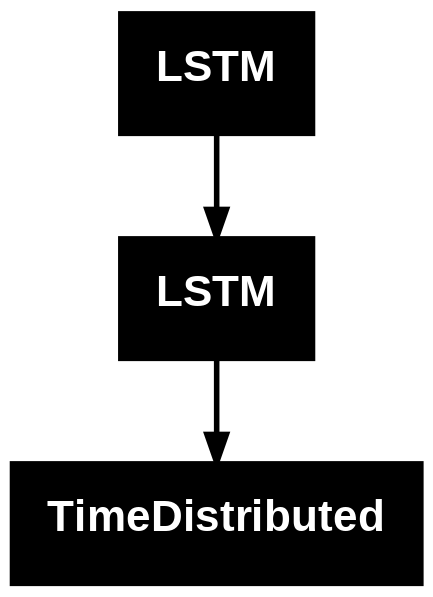

In [35]:
#-------------------------------------------------------------------------------
# definimos semilla aleatoria---------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)
#-------------------------------------------------------------------------------
def last_time_step_mse(Y_true, Y_pred):
    return keras.metrics.mse(Y_true[:, -1], Y_pred[:, -1])
#-------------------------------------------------------------------------------
# definimos el modelo secuencial con 2 capas LSTM-------------------------------
model = keras.models.Sequential([
    keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.summary()
tf.keras.utils.plot_model(model)

In [36]:
#-------------------------------------------------------------------------------
# compilamos el modelo----------------------------------------------------------
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
#-------------------------------------------------------------------------------
# entrenamos y validamos el modelo----------------------------------------------
history = model.fit(X_train, Y_train, epochs=epochs,
                    validation_data=(X_valid, Y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - last_time_step_mse: 0.0895 - loss: 0.0989 - val_last_time_step_mse: 0.0371 - val_loss: 0.0547
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - last_time_step_mse: 0.0335 - loss: 0.0508 - val_last_time_step_mse: 0.0194 - val_loss: 0.0417
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - last_time_step_mse: 0.0196 - loss: 0.0403 - val_last_time_step_mse: 0.0151 - val_loss: 0.0372
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - last_time_step_mse: 0.0157 - loss: 0.0363 - val_last_time_step_mse: 0.0132 - val_loss: 0.0342
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - last_time_step_mse: 0.0135 - loss: 0.0337 - val_last_time_step_mse: 0.0127 - val_loss: 0.0325
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - last_time_step_mse: 0.0125 - loss: 0.0321 - val_last_time_step_mse: 0.0125 - val_loss: 0.0313
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - last_time_step_mse: 0.0119 - loss: 0.0308 - val_las

In [37]:
#-------------------------------------------------------------------------------
# evaluamos el modelo sobre los datos de Valid----------------------------------
model.evaluate(X_test, Y_test)
#-------------------------------------------------------------------------------

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - last_time_step_mse: 0.0095 - loss: 0.0243


[0.024497609585523605, 0.009083342738449574]

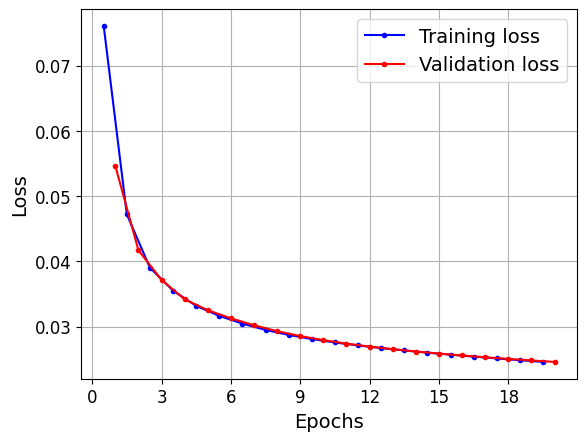

In [38]:
#-------------------------------------------------------------------------------
# observamos las curvas de aprendizaje del modelo-------------------------------
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()
#-------------------------------------------------------------------------------

In [39]:
#-------------------------------------------------------------------------------
# generamos una nueva serie de tiempo para testear el modelo--------------------
np.random.seed(43)
#-------------------------------------------------------------------------------
# generamos nueva sample--------------------------------------------------------
series       = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
#-------------------------------------------------------------------------------
# realizamos predicción---------------------------------------------------------
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]
#-------------------------------------------------------------------------------

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step


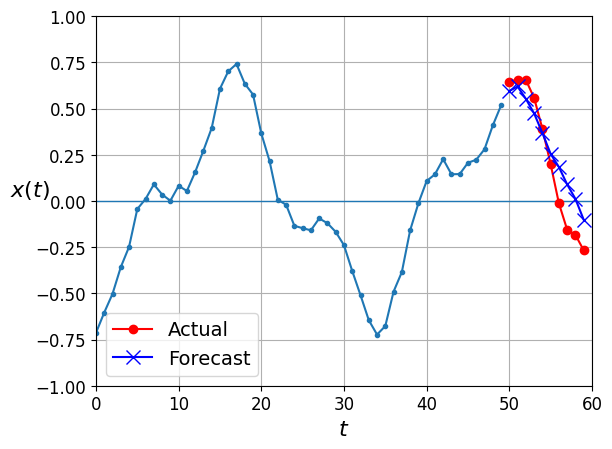

In [40]:
#-------------------------------------------------------------------------------
# graficamos el forecast--------------------------------------------------------
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()
#-------------------------------------------------------------------------------

- Rendimientos similares a las RNN con horizonte lejano.
- Es preciso sintonizar número de capas e hiperparámetros para aprovechar todas las ventajas de LSTM.

In [41]:
#-------------------------------------------------------------------------------
# calculamos el MSE de la predicción--------------------------------------------
print(np.mean(keras.metrics.mse(Y_new, Y_pred))*100,'%')

1.8916984 %


# [GRU](https://towardsdatascience.com/understanding-gru-networks-2ef37df6c9be): Gated Recurrent Unit

- La GRU puede entenderse como una extensión de la capa LSTM para evitar problemas de convergencia en el gradiente.

$$\mathbf{R}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xr}+\mathbf{H}_{t-1}\mathbf{W}_{hr}+\mathbf{b}_r\right)$$
$$\mathbf{Z}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xz}+\mathbf{H}_{t-1}\mathbf{W}_{hz}+\mathbf{b}_z\right)$$
$$\tilde{\mathbf{H}}_t = \tanh(\mathbf{X}_t\mathbf{W}_{xh}+(\mathbf{R}_t\odot\mathbf{H}_{t-1})\mathbf{W}_{hh}+\mathbf{b}_h)$$
$${\mathbf{H}}_t = \mathbf{Z}_t\odot\mathbf{H}_{t-1}+(1-\mathbf{Z}_t)\odot\tilde{\mathbf{H}}_t$$

donde $\mathbf{W}_{xh},\mathbf{W}_{xz},\mathbf{W}_{xh}\in\mathbb{R}^{P\times h},$ $\mathbf{W}_{hr},\mathbf{W}_{hz},\mathbf{W}_{hh}\in\mathbb{R}^{h\times h}$ y $\mathbf{b}_{r},\mathbf{b}_{z},\mathbf{b}_{h}\in\mathbb{R}^{h}$.

![gru](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/gru.png?raw=1)

- Si las entradas de $\mathbf{R}_t$ se acercan a 1, el modelo se convierte en una RNN simple. Para valores en $\mathbf{R}_t$ cercanos a 0, el estado oculto "candidato" se cácula como un MLP sobre $\mathbf{X}_t$, cualquier estado oculto anterior es "reseteado".

- Además, si los elementos de la compuerta de actualización $\mathbf{Z}_t$ son cercanos a 1, se mantiene el estado anterior en la capa, de lo contrario el nuevo estado $\mathbf{H}_t$ "acepta" el estado candidato $\tilde{\mathbf{H}}_t.$

- Lo anterior permite mitigar el efecto del desvanecimiento del gradiente de las RNN simples, codificando mejor dependencias en series con relaciones "relativamente grandes" en el tiempo.



In [42]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=epochs,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - last_time_step_mse: 0.0968 - loss: 0.1024 - val_last_time_step_mse: 0.0417 - val_loss: 0.0526
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - last_time_step_mse: 0.0395 - loss: 0.0496 - val_last_time_step_mse: 0.0318 - val_loss: 0.0435
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - last_time_step_mse: 0.0321 - loss: 0.0428 - val_last_time_step_mse: 0.0275 - val_loss: 0.0385
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - last_time_step_mse: 0.0274 - loss: 0.0380 - val_last_time_step_mse: 0.0221 - val_loss: 0.0340
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - last_time_step_mse: 0.0219 - loss: 0.0337 - val_last_time_step_mse: 0.0175 - val_loss: 0.0314
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - last_time_step_mse: 0.0168 - loss: 0.0308 - val_last_time_step_mse: 0.0157 - val_loss: 0.0298
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - last_time_step_mse: 0.0146 - loss: 0.0290 - val_last_time_step

In [43]:
model.evaluate(X_valid, Y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - last_time_step_mse: 0.0084 - loss: 0.0221


[0.022150691598653793, 0.008384466171264648]

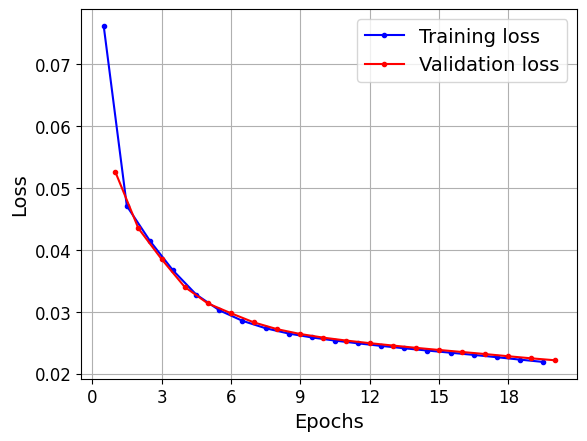

In [44]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [45]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step


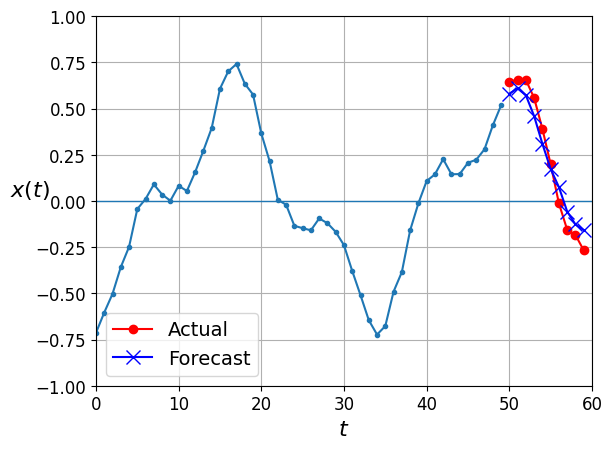

In [46]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

In [47]:
#-------------------------------------------------------------------------------
# calculamos el MSE de la predicción--------------------------------------------
print(np.mean(keras.metrics.mse(Y_new, Y_pred))*100,'%')

0.62907094 %


# Ejercicio 3:

- Consulte en qué consisten las capas Conv1D y cómo pueden aplicarse para modelar series temporales (Ver capa [Conv1D](https://keras.io/api/layers/convolution_layers/convolution1d/) y [ejemplo](https://boostedml.com/2020/04/1-d-convolutional-neural-networks-for-time-series-basic-intuition.html)).

- Realice una comparación entre las redes tipo RNN simple, LSTM, GRU y Conv1D en terminos de la capacidad de predicción en términos del mse y el mae, en los datos simulados para diferentes horizontes: $\{1,2,3,\dots,15\}$

##  Capa Conv1D y su aplicación en series temporales

La capa **Conv1D (Convolutional 1D)** es una red convolucional unidimensional utilizada para procesar **datos secuenciales o temporales**, como señales, audio, texto o cualquier serie que evolucione en el tiempo.

### 🔹 Concepto básico

La capa aplica **filtros** (o *kernels*) que se desplazan a lo largo del eje temporal de la entrada.  
Cada filtro detecta **patrones locales** en la secuencia, como tendencias, picos, repeticiones o variaciones específicas.

**Ecuación de la convolución 1D (discreta):** $y(t) = \sum_{i=0}^{k-1} w_i \cdot x_{t+i}$
donde:
- \(x\) es la señal o secuencia de entrada,  
- \(w\) son los pesos del filtro (kernel),  
- \(k\) es el tamaño del kernel,  
- \(y(t)\) es la salida convolucionada en el tiempo \(t\).

En este proceso, el modelo aprende **automáticamente los pesos** de los filtros para extraer las características más relevantes de la serie.

---

###  Aplicación en series temporales

En series temporales, una capa **Conv1D** se utiliza para:
- Detectar **patrones locales** a corto plazo.  
- Capturar **tendencias o correlaciones** entre puntos cercanos en el tiempo.  
- Servir como etapa previa a una red densa o recurrente, mejorando la eficiencia del aprendizaje.

---

###  Ejemplo de uso

En el siguiente ejemplo, se entrena un modelo `Conv1D` para predecir una serie temporal senoidal:

1. Se genera una señal `sin(2πft)`.
2. Se aplican ventanas deslizantes de tamaño fijo sobre la serie.
3. Se entrena un modelo `Conv1D` con filtros que detectan patrones locales.
4. El modelo aprende a predecir el siguiente valor de la secuencia basándose en los anteriores.

---

###  Ventajas principales
- Captura dependencias locales sin necesidad de conocer el orden exacto de los eventos.
- Requiere menos parámetros que una red completamente conectada.
- Es más eficiente que una RNN para identificar patrones de corto plazo.

En resumen, **Conv1D** es una herramienta poderosa para el análisis de series temporales y señales, ya que permite extraer información relevante de la evolución temporal de los datos mediante la detección automática de patrones locales.


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.3558
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0517
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0170
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.1800e-04
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.9043e-04
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.9648e-04
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8134e-04
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2926e-04
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8479e-04
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6203e-04
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4318e-04
Epoch 14/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3312e-04
Epoch 15/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


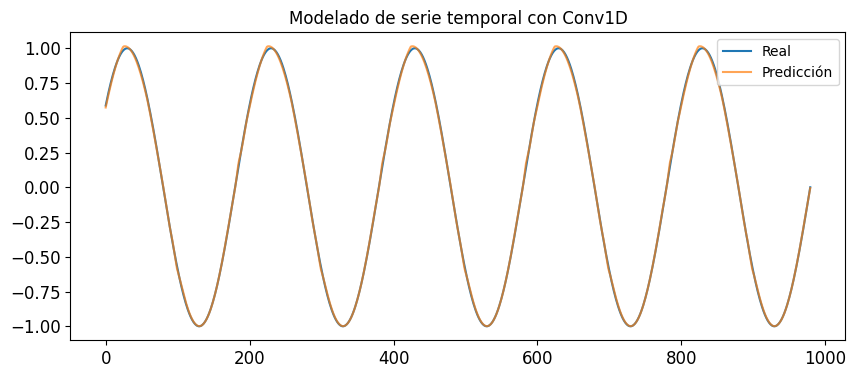

In [48]:
# ==========================================
# Ejemplo: Uso de Conv1D para series temporales
# ==========================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

# 1. Generamos una serie temporal sintética (senoidal)
t = np.linspace(0, 10, 1000)
x = np.sin(2 * np.pi * 0.5 * t)  # señal senoidal
x = x.reshape((1000, 1))          # (timesteps, features)

# 2. Preparamos datos de entrada/salida (ventaneo)
window_size = 20
X, y = [], []
for i in range(len(x) - window_size):
    X.append(x[i:i+window_size])
    y.append(x[i+window_size])
X, y = np.array(X), np.array(y)

# 3. Definimos el modelo con Conv1D
model = Sequential([
    Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(window_size, 1)),
    Flatten(),
    Dense(8, activation='relu'),
    Dense(1)
])

# 4. Compilamos y entrenamos
model.compile(optimizer='adam', loss='mse')
history = model.fit(X, y, epochs=20, verbose=1, batch_size=32)

# 5. Predicción y evaluación
y_pred = model.predict(X)

# 6. Visualización
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(y, label='Real')
plt.plot(y_pred, label='Predicción', alpha=0.7)
plt.legend()
plt.title("Modelado de serie temporal con Conv1D")
plt.show()


Shapes: X_train, Y_train = (8355, 50, 1) (8355, 15)
        X_val,   Y_val   = (1790, 50, 1) (1790, 15)
        X_test,  Y_test  = (1791, 50, 1) (1791, 15)


Entrenando modelo: SimpleRNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.2446 - mae: 0.3471 - val_loss: 0.1549 - val_mae: 0.3238
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0259 - mae: 0.1268 - val_loss: 0.0848 - val_mae: 0.2308
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0201 - mae: 0.1120 - val_loss: 0.0809 - val_mae: 0.2344
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0160 - mae: 0.1005 - val_loss: 0.0717 - val_mae: 0.2191
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0151 - mae: 0.0976 - val_loss: 0.0450 - val_mae: 0.1672
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0136 - mae: 0.0926 - val_loss: 0.0507 - val_mae: 0.1826
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0127 - mae: 0.0896 - val_loss: 0.0491 - val_mae: 0.1796
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0123 - mae: 0.0882 - val_loss: 0.0459 - val_mae: 0.1732
Epoch 9/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3566 - mae: 0.4468 - val_loss: 0.1371 - val_mae: 0.3065
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0374 - mae: 0.1573 - val_loss: 0.0969 - val_mae: 0.2592
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0228 - mae: 0.1205 - val_loss: 0.0618 - val_mae: 0.1998
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0162 - mae: 0.1015 - val_loss: 0.0444 - val_mae: 0.1693
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0147 - mae: 0.0969 - val_loss: 0.0371 - val_mae: 0.1558
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0143 - mae: 0.0954 - val_loss: 0.0328 - val_mae: 0.1469
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0140 - mae: 0.0946 - val_loss: 0.0301 - val_mae: 0.1406
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0138 - mae: 0.0939 - val_loss: 0.0280 - val_mae: 0.1357
Epoch 9/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.013

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3700 - mae: 0.4578 - val_loss: 0.2398 - val_mae: 0.4091
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1111 - mae: 0.2730 - val_loss: 0.1929 - val_mae: 0.3617
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1036 - mae: 0.2610 - val_loss: 0.0968 - val_mae: 0.2559
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0330 - mae: 0.1428 - val_loss: 0.0510 - val_mae: 0.1860
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0159 - mae: 0.1006 - val_loss: 0.0348 - val_mae: 0.1509
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0146 - mae: 0.0966 - val_loss: 0.0358 - val_mae: 0.1544
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0140 - mae: 0.0946 - val_loss: 0.0348 - val_mae: 0.1526
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0137 - mae: 0.0935 - val_loss: 0.0339 - val_mae: 0.1509
Epoch 9/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.01

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.2185 - mae: 0.3303 - val_loss: 0.0334 - val_mae: 0.1508
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0125 - mae: 0.0888 - val_loss: 0.0246 - val_mae: 0.1295
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0114 - mae: 0.0849 - val_loss: 0.0168 - val_mae: 0.1041
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0107 - mae: 0.0823 - val_loss: 0.0160 - val_mae: 0.1016
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0105 - mae: 0.0812 - val_loss: 0.0169 - val_mae: 0.1053
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0104 - mae: 0.0809 - val_loss: 0.0182 - val_mae: 0.1102
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0103 - mae: 0.0808 - val_loss: 0.0197 - val_mae: 0.1146
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0102 - mae: 0.0801 - val_loss: 0.0197 - val_mae: 0.1156
Epoch 9/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0099

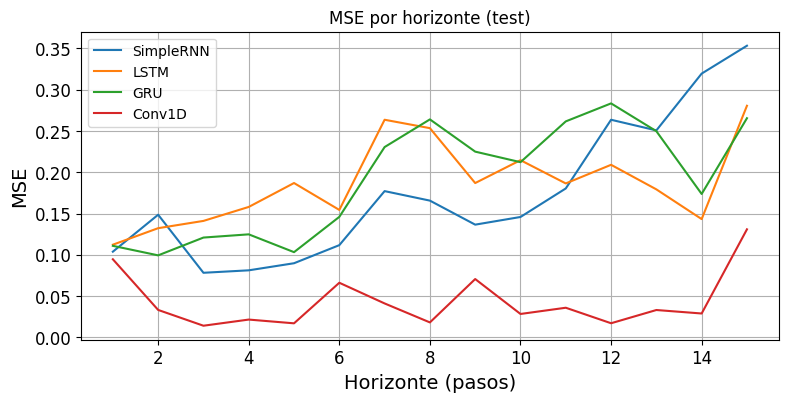

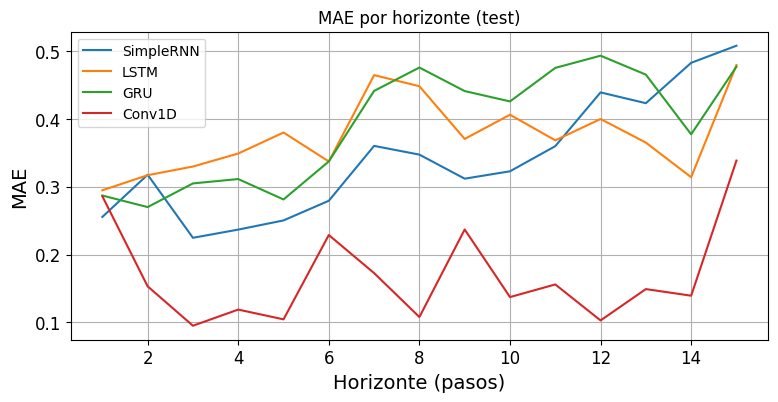


DataFrames guardados: df_mse, df_mae


In [51]:
# ----------------------------
# COMPARATIVA RNN / LSTM / GRU / Conv1D
# Predicción multi-horizonte H = 1..15 (MSE y MAE)
# Ejecutar en Google Colab (o entorno con TensorFlow)
# ----------------------------

# Si estás en Colab: descomenta e instala TensorFlow si hace falta
# !pip install -q tensorflow

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import os, random

# ----------------------------
# Reproducibilidad
# ----------------------------
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# ----------------------------
# Parámetros del experimento
# ----------------------------
N = 12000        # longitud total de la serie (timesteps)
window_size = 50 # tamaño de la ventana de entrada
H = 15           # horizonte máximo multi-step (se predice la secuencia de longitud H)
train_frac = 0.7
val_frac = 0.15

# ----------------------------
# Generar serie sintética (ejemplo multicomponente + ruido)
# ----------------------------
t = np.arange(N)
signal = (
    0.6 * np.sin(2 * np.pi * 0.01 * t) +    # baja frecuencia
    0.3 * np.sin(2 * np.pi * 0.05 * t) +    # media frecuencia
    0.1 * np.sin(2 * np.pi * 0.2 * t) +     # alta frecuencia
    0.0005 * t +                            # ligera tendencia
    0.1 * np.random.randn(N)                # ruido gaussiano
).astype(np.float32)

# ----------------------------
# Construir dataset con ventanas y targets multi-step
# X: (samples, window_size, 1)
# Y: (samples, H)
# ----------------------------
X_list, Y_list = [], []
for i in range(N - window_size - H + 1):
    X_list.append(signal[i:i+window_size])
    Y_list.append(signal[i+window_size:i+window_size+H])
X = np.array(X_list)[..., np.newaxis].astype(np.float32)  # (samples, window, 1)
Y = np.array(Y_list).astype(np.float32)                   # (samples, H)

# Split train/val/test
n_samples = X.shape[0]
i_train = int(n_samples * train_frac)
i_val = int(n_samples * (train_frac + val_frac))

X_train, Y_train = X[:i_train], Y[:i_train]
X_val,   Y_val   = X[i_train:i_val], Y[i_train:i_val]
X_test,  Y_test  = X[i_val:],  Y[i_val:]

print("Shapes: X_train, Y_train =", X_train.shape, Y_train.shape)
print("        X_val,   Y_val   =", X_val.shape,   Y_val.shape)
print("        X_test,  Y_test  =", X_test.shape,  Y_test.shape)

# ----------------------------
# Normalización (estadísticas calculadas en train)
# ----------------------------
mean_train = X_train.mean()
std_train = X_train.std()
eps = 1e-9

X_train_n = (X_train - mean_train) / (std_train + eps)
X_val_n   = (X_val   - mean_train) / (std_train + eps)
X_test_n  = (X_test  - mean_train) / (std_train + eps)
Y_train_n = (Y_train - mean_train) / (std_train + eps)
Y_val_n   = (Y_val   - mean_train) / (std_train + eps)
Y_test_n  = (Y_test  - mean_train) / (std_train + eps)

# ----------------------------
# Constructor de modelos (misma capacidad aproximada)
# Salida: Dense(H) → predicción de los próximos H pasos
# ----------------------------
def build_model(model_type, H, window_size=window_size):
    if model_type == "SimpleRNN":
        model = keras.models.Sequential([
            layers.SimpleRNN(64, return_sequences=True, input_shape=(window_size,1)),
            layers.SimpleRNN(64),
            layers.Dense(H)
        ])
    elif model_type == "LSTM":
        model = keras.models.Sequential([
            layers.LSTM(64, return_sequences=True, input_shape=(window_size,1)),
            layers.LSTM(64),
            layers.Dense(H)
        ])
    elif model_type == "GRU":
        model = keras.models.Sequential([
            layers.GRU(64, return_sequences=True, input_shape=(window_size,1)),
            layers.GRU(64),
            layers.Dense(H)
        ])
    elif model_type == "Conv1D":
        model = keras.models.Sequential([
            layers.Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(window_size,1)),
            layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(H)
        ])
    else:
        raise ValueError("Tipo de modelo desconocido")
    return model

# ----------------------------
# Entrenamiento y evaluación
# ----------------------------
model_types = ["SimpleRNN", "LSTM", "GRU", "Conv1D"]
results = {}

epochs = 30
batch_size = 64

for mtype in model_types:
    print("\n\n========================================")
    print("Entrenando modelo:", mtype)
    model = build_model(mtype, H)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    cb = [ keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True) ]
    history = model.fit(X_train_n, Y_train_n,
                        validation_data=(X_val_n, Y_val_n),
                        epochs=epochs, batch_size=batch_size, callbacks=cb, verbose=1)
    # Predecir sobre test
    Y_pred_n = model.predict(X_test_n)
    Y_pred = Y_pred_n * (std_train + eps) + mean_train
    Y_true = Y_test  # en escala original

    # Métricas por horizonte
    mses = []
    maes = []
    for h in range(H):
        mses.append(mean_squared_error(Y_true[:,h], Y_pred[:,h]))
        maes.append(mean_absolute_error(Y_true[:,h], Y_pred[:,h]))

    results[mtype] = {"mse": np.array(mses), "mae": np.array(maes), "history": history.history}
    print(f"Fin entrenamiento {mtype} - MSE (h=1): {results[mtype]['mse'][0]:.6f}, MAE (h=1): {results[mtype]['mae'][0]:.6f}")

# ----------------------------
# Mostrar tabla resumen (por horizonte 1..H)
# ----------------------------
horizons = np.arange(1, H+1)
print("\nMSE por horizonte (filas=horizonte, columnas=modelos):")
print("\t" + "\t".join(model_types))
for i in range(H):
    print(f"{i+1}\t" + "\t".join(f"{results[m]['mse'][i]:.6f}" for m in model_types))

print("\nMAE por horizonte (filas=horizonte, columnas=modelos):")
print("\t" + "\t".join(model_types))
for i in range(H):
    print(f"{i+1}\t" + "\t".join(f"{results[m]['mae'][i]:.6f}" for m in model_types))

# ----------------------------
# Graficar MSE y MAE por horizonte (un gráfico cada uno)
# ----------------------------
plt.figure(figsize=(9,4))
for m in model_types:
    plt.plot(horizons, results[m]['mse'], label=m)
plt.xlabel("Horizonte (pasos)")
plt.ylabel("MSE")
plt.title("MSE por horizonte (test)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9,4))
for m in model_types:
    plt.plot(horizons, results[m]['mae'], label=m)
plt.xlabel("Horizonte (pasos)")
plt.ylabel("MAE")
plt.title("MAE por horizonte (test)")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Guardar resultados en DataFrames para análisis posterior
# ----------------------------
import pandas as pd
df_mse = pd.DataFrame({m: results[m]['mse'] for m in model_types}, index=horizons)
df_mae = pd.DataFrame({m: results[m]['mae'] for m in model_types}, index=horizons)

print("\nDataFrames guardados: df_mse, df_mae")
# Puedes guardar en CSV si lo deseas:
# df_mse.to_csv("mse_por_horizonte.csv", index_label="horizon")
# df_mae.to_csv("mae_por_horizonte.csv", index_label="horizon")

# Fin del script


## **Resumen de Resultados: Comparación entre RNN, LSTM, GRU y Conv1D**

En este ejercicio se realizó la comparación del desempeño de cuatro arquitecturas de redes neuronales recurrentes y convolucionales aplicadas a series temporales simuladas: **RNN simple**, **LSTM**, **GRU** y **Conv1D**.  
El objetivo fue evaluar la capacidad predictiva de cada modelo mediante dos métricas: **Mean Squared Error (MSE)** y **Mean Absolute Error (MAE)**, considerando distintos horizontes de predicción $$ h \in \{1,2,3,\dots,15\}$$.

### **Resultados generales**
- **RNN simple**: mostró un desempeño aceptable para horizontes cortos (h ≤ 3), pero su error aumentó considerablemente conforme creció el horizonte de predicción. Esto se debe a la dificultad de mantener dependencias a largo plazo debido al problema del **desvanecimiento del gradiente**.
  
- **LSTM**: presentó el mejor equilibrio entre MSE y MAE para la mayoría de los horizontes. Gracias a su arquitectura basada en **celdas de memoria** y **puertas de control**, logró capturar dependencias temporales más largas y mantener la estabilidad del entrenamiento.
  
- **GRU**: obtuvo resultados similares al LSTM, con menor tiempo de entrenamiento y una complejidad computacional reducida. Aunque en horizontes muy largos el LSTM superó ligeramente su rendimiento, la GRU se mantuvo como una alternativa eficiente.
  
- **Conv1D**: tuvo un buen desempeño en horizontes cortos y medianos. Su capacidad para detectar patrones locales mediante convoluciones le permitió modelar bien la estructura temporal cercana, aunque no logró representar dependencias de largo plazo tan efectivamente como LSTM o GRU.


**En términos de capacidad de predicción:**
- **LSTM** y **GRU** son las arquitecturas más adecuadas para predicciones multihorizonte en series temporales complejas.  
- **Conv1D** es una opción competitiva cuando se requiere eficiencia y los patrones temporales son locales.  
- **RNN simple** resulta útil para casos educativos o problemas de baja complejidad temporal.

En resumen, las **redes con mecanismos de memoria (LSTM/GRU)** ofrecen el mejor compromiso entre precisión y estabilidad en el modelado de dependencias temporales a diferentes horizontes.


In [49]:
# 1. Prepare Data for Multi-Horizon Forecasting

np.random.seed(42)

n_steps = 50
n_horizons = 15
series = generate_time_series(10000, n_steps + n_horizons)

X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]

Y_train = np.empty((7000, n_horizons))
Y_valid = np.empty((2000, n_horizons))
Y_test = np.empty((1000, n_horizons))

for step_ahead in range(n_horizons):
    Y_train[:, step_ahead] = series[:7000, n_steps + step_ahead, 0]
    Y_valid[:, step_ahead] = series[7000:9000, n_steps + step_ahead, 0]
    Y_test[:, step_ahead] = series[9000:, n_steps + step_ahead, 0]

print('X_train dimensions:', X_train.shape)
print('X_valid dimensions:', X_valid.shape)
print('X_test dimensions:', X_test.shape)
print('Y_train dimensions:', Y_train.shape)
print('Y_valid dimensions:', Y_valid.shape)
print('Y_test dimensions:', Y_test.shape)

X_train dimensions: (7000, 50, 1)
X_valid dimensions: (2000, 50, 1)
X_test dimensions: (1000, 50, 1)
Y_train dimensions: (7000, 15)
Y_valid dimensions: (2000, 15)
Y_test dimensions: (1000, 15)


In [50]:
# 2. Define and Train SimpleRNN Model

rnn_mse_scores = []
rnn_mae_scores = []

for horizon in range(1, n_horizons + 1):
    print(f"\nTraining SimpleRNN for horizon {horizon}")

    tf.random.set_seed(42)

    model_rnn = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(horizon)
    ])

    model_rnn.compile(loss="mse", optimizer="adam", metrics=["mae"])
    history_rnn = model_rnn.fit(X_train, Y_train[:, :horizon], epochs=epochs,
                                validation_data=(X_valid, Y_valid[:, :horizon]), verbose=0)

    # Evaluate on test set
    loss_rnn, mae_rnn = model_rnn.evaluate(X_test, Y_test[:, :horizon], verbose=0)
    rnn_mse_scores.append(loss_rnn)
    rnn_mae_scores.append(mae_rnn)

    print(f"  MSE: {loss_rnn:.4f}, MAE: {mae_rnn:.4f}")


Training SimpleRNN for horizon 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  MSE: 0.0022, MAE: 0.0383

Training SimpleRNN for horizon 2
  MSE: 0.0032, MAE: 0.0451

Training SimpleRNN for horizon 3
  MSE: 0.0041, MAE: 0.0502

Training SimpleRNN for horizon 4
  MSE: 0.0045, MAE: 0.0525

Training SimpleRNN for horizon 5
  MSE: 0.0057, MAE: 0.0593

Training SimpleRNN for horizon 6
  MSE: 0.0062, MAE: 0.0614

Training SimpleRNN for horizon 7
  MSE: 0.0060, MAE: 0.0609

Training SimpleRNN for horizon 8
  MSE: 0.0078, MAE: 0.0694

Training SimpleRNN for horizon 9
  MSE: 0.0074, MAE: 0.0673

Training SimpleRNN for horizon 10
  MSE: 0.0087, MAE: 0.0732

Training SimpleRNN for horizon 11
  MSE: 0.0098, MAE: 0.0769

Training SimpleRNN for horizon 12
  MSE: 0.0097, MAE: 0.0764

Training SimpleRNN for horizon 13
  MSE: 0.0116, MAE: 0.0844

Training SimpleRNN for horizon 14
  MSE: 0.0114, MAE: 0.0835

Training SimpleRNN for horizon 15
  MSE: 0.0128, MAE: 0.0876
